In [2]:
import numpy as np
data = np.load('/content/drive/MyDrive/cifar10_data.npz')
x_train, y_train = data['x_train'], data['y_train']
x_test, y_test = data['x_test'], data['y_test']
print("Raw loaded min/max:", x_train.min(), x_train.max())

Raw loaded min/max: 0.0 1.0


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score)
import seaborn as sns

In [4]:
import os

In [5]:
import matplotlib as mpl
import matplotlib.font_manager as fm

# Path to your uploaded font
font_path = "/content/times.ttf"      # Change if the filename is different

# Register the font
fm.fontManager.addfont(font_path)

# Get the font name stored inside the TTF
font_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded Font:", font_name)

# Set it as the default font
mpl.rcParams['font.family'] = font_name
mpl.rcParams['font.size'] = 16
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16

def save_eps_or_pdf(filename, dpi=600, max_size_kb=100):

    eps_name = filename + ".eps"

    plt.savefig(
        eps_name,
        format='eps',
        dpi=dpi,
        bbox_inches='tight'
    )

    size_kb = os.path.getsize(eps_name) / 1024

    if size_kb > max_size_kb:
        os.remove(eps_name)
        pdf_name = filename + ".pdf"
        plt.savefig(
            pdf_name,
            format='pdf',
            bbox_inches='tight'
        )
        print(f"{pdf_name} saved (EPS was {size_kb:.1f} KB)")
    else:
        print(f"{eps_name} saved ({size_kb:.1f} KB)")

Loaded Font: Times New Roman


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


x_train = x_train.astype('float32')  # already [0,1], no need to divide
x_test = x_test.astype('float32')

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("x_train min/max:", x_train.min(), x_train.max())  # should be 0.0 1.0

x_train min/max: 0.0 1.0


In [10]:
IMG_SIZE = 64

def resize_batch(images, size):
    return tf.image.resize(images, (size, size)).numpy()

print("Resizing images for VGG16 input...")
x_train_r = resize_batch(x_train, IMG_SIZE)
x_test_r = resize_batch(x_test, IMG_SIZE)

print("x_train_r min/max after fix:", x_train_r.min(), x_train_r.max())  # should be ~0.0 to ~1.0

Resizing images for VGG16 input...
x_train_r min/max after fix: 0.0 1.0


In [21]:
print("x_train min/max:", x_train.min(), x_train.max())
print("x_train_r min/max:", x_train_r.min(), x_train_r.max())

x_train min/max: 0.0 1.0
x_train_r min/max: 0.0 1.0


Resizing images for VGG16 input...
Resized shapes: (50000, 64, 64, 3) (10000, 64, 64, 3)


In [22]:
# ------------------------------------------------------------
# Task 2: Transfer Learning Setup - VGG16
# ------------------------------------------------------------
base_model = VGG16(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze convolutional base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters (frozen base): {trainable_params:,}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Total Parameters: 14,848,586
Trainable Parameters (frozen base): 133,898


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.4979 - loss: 1.4377 - val_accuracy: 0.5949 - val_loss: 1.1527
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.5811 - loss: 1.1927 - val_accuracy: 0.6186 - val_loss: 1.0892
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6046 - loss: 1.1326 - val_accuracy: 0.6322 - val_loss: 1.0658
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6193 - loss: 1.0900 - val_accuracy: 0.6459 - val_loss: 1.0197
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6289 - loss: 1.0650 - val_accuracy: 0.6479 - val_loss: 1.0064
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6348 - loss: 1.0403 - val_accuracy: 0.6433 - val_loss: 1.0083
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6440 - loss: 1.0203 - val_accuracy: 0.6615 - val_loss: 0.9728
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6506 -

tl_frozen_curves.eps saved (42.8 KB)


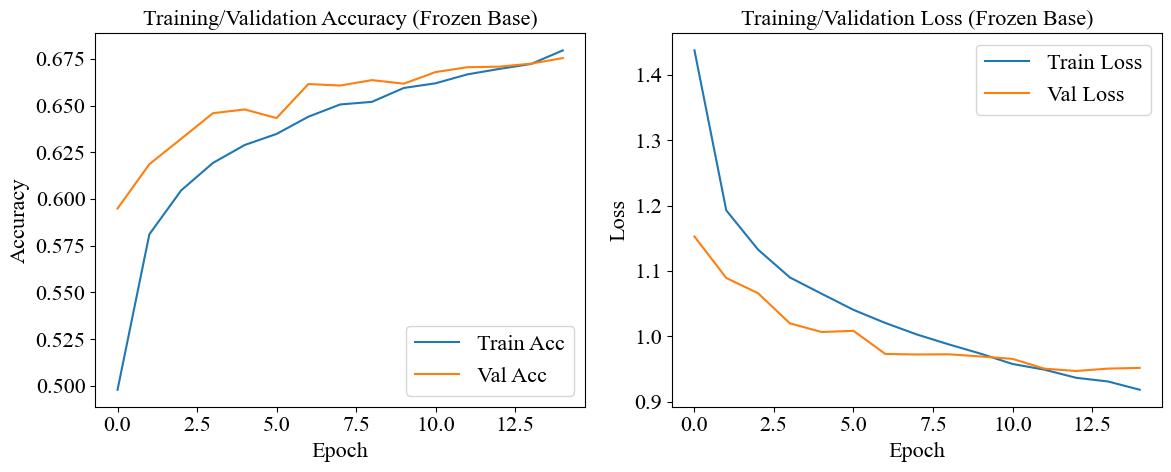

Frozen-base Test Accuracy: 0.6599


In [23]:

# ------------------------------------------------------------
# Task 3: Model Training (frozen base)
# ------------------------------------------------------------
BATCH_SIZE = 32
EPOCHS = 15

start = time.time()
history = model.fit(x_train_r, y_train_cat,
                     batch_size=BATCH_SIZE,
                     epochs=EPOCHS,
                     validation_split=0.2,
                     verbose=1)
train_time_frozen = time.time() - start
print(f"\nFrozen-base training time: {train_time_frozen:.2f}s")

# Plot curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Training/Validation Accuracy (Frozen Base)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training/Validation Loss (Frozen Base)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
save_eps_or_pdf("tl_frozen_curves")
plt.show()

test_loss, test_acc_frozen = model.evaluate(x_test_r, y_test_cat, verbose=0)
print(f"Frozen-base Test Accuracy: {test_acc_frozen:.4f}")


Epoch 1/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.7181 - loss: 0.8028 - val_accuracy: 0.7311 - val_loss: 0.7967
Epoch 2/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.7748 - loss: 0.6337 - val_accuracy: 0.7628 - val_loss: 0.6997
Epoch 3/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.8106 - loss: 0.5281 - val_accuracy: 0.7699 - val_loss: 0.6861
Epoch 4/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.8411 - loss: 0.4453 - val_accuracy: 0.7783 - val_loss: 0.6832
Epoch 5/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.8651 - loss: 0.3752 - val_accuracy: 0.7898 - val_loss: 0.6515
Epoch 6/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.8853 - loss: 0.3203 - val_accuracy: 0.7909 - val_loss: 0.6640
Epoch 7/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.9028 - loss: 0.2714 - val_accuracy: 0.7943 - val_loss: 0.6733
Epoch 8/8
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.9172 - loss: 0

tl_finetuned_curves.eps saved (37.7 KB)


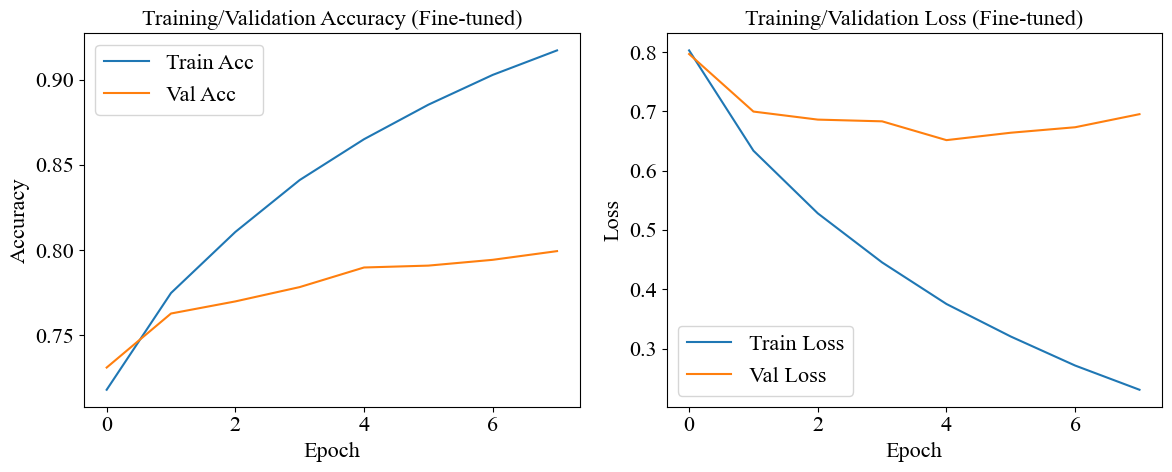


Before fine-tuning Test Accuracy: 0.6599
After fine-tuning Test Accuracy:  0.7860


In [24]:

# ------------------------------------------------------------
# Task 4: Fine Tuning - unfreeze last conv block of VGG16
# ------------------------------------------------------------
base_model.trainable = True
# VGG16's last block is block5 (conv layers block5_conv1-3 + pool)
for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

FT_EPOCHS = 8
start = time.time()
history_ft = model.fit(x_train_r, y_train_cat,
                        batch_size=BATCH_SIZE,
                        epochs=FT_EPOCHS,
                        validation_split=0.2,
                        verbose=1)
train_time_ft = time.time() - start
print(f"\nFine-tuning training time: {train_time_ft:.2f}s")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['accuracy'], label='Train Acc')
plt.plot(history_ft.history['val_accuracy'], label='Val Acc')
plt.title("Training/Validation Accuracy (Fine-tuned)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ft.history['loss'], label='Train Loss')
plt.plot(history_ft.history['val_loss'], label='Val Loss')
plt.title("Training/Validation Loss (Fine-tuned)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
save_eps_or_pdf("tl_finetuned_curves")
plt.show()

test_loss_ft, test_acc_ft = model.evaluate(x_test_r, y_test_cat, verbose=0)
print(f"\nBefore fine-tuning Test Accuracy: {test_acc_frozen:.4f}")
print(f"After fine-tuning Test Accuracy:  {test_acc_ft:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step

Precision: 0.7906
Recall: 0.7860
F1-score: 0.7866

Classification Report:

              precision    recall  f1-score   support

    airplane       0.89      0.82      0.85      1000
  automobile       0.86      0.89      0.87      1000
        bird       0.76      0.73      0.75      1000
         cat       0.61      0.61      0.61      1000
        deer       0.80      0.67      0.73      1000
         dog       0.62      0.75      0.68      1000
        frog       0.76      0.85      0.80      1000
       horse       0.83      0.81      0.82      1000
        ship       0.91      0.88      0.89      1000
       truck       0.86      0.87      0.86      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

tl_confusion_matrix.pdf saved (EPS was 1715.4 KB)


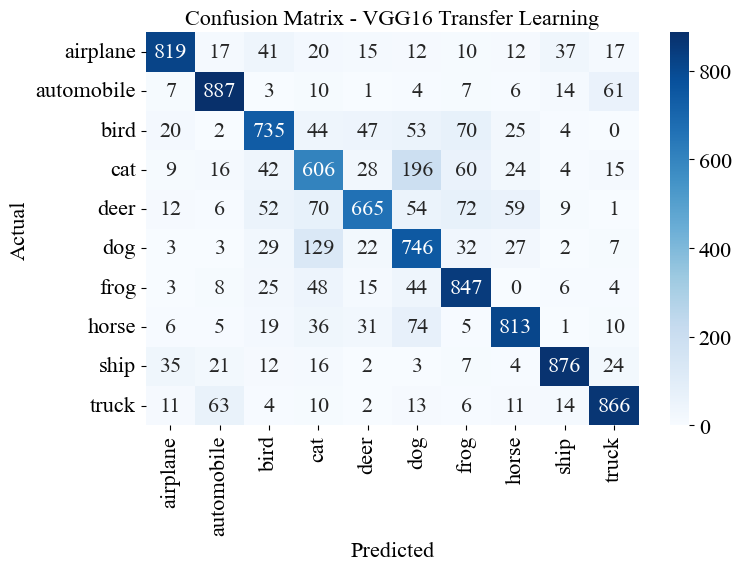


Total Parameters: 14,848,586
Total Training Time (frozen + fine-tune): 936.91s


In [25]:


# ------------------------------------------------------------
# Task 5: Model Evaluation
# ------------------------------------------------------------
y_pred_probs = model.predict(x_test_r)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - VGG16 Transfer Learning")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
save_eps_or_pdf("tl_confusion_matrix")
plt.show()

print(f"\nTotal Parameters: {total_params:,}")
print(f"Total Training Time (frozen + fine-tune): {train_time_frozen + train_time_ft:.2f}s")

In [13]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# x_train_r / x_test_r are currently [0,1] floats - convert to [0,255] then apply ResNet50 preprocessing
x_train_resnet = preprocess_input(x_train_r * 255.0)
x_test_resnet = preprocess_input(x_test_r * 255.0)
IMG_SIZE_RESNET = 64

base_model_resnet = ResNet50(weights='imagenet', include_top=False,
                              input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3))
base_model_resnet.trainable = False

model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_resnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

start = time.time()
history_resnet = model_resnet.fit(x_train_resnet, y_train_cat,
                                   batch_size=32, epochs=15,
                                   validation_split=0.2, verbose=1)
resnet_train_time = time.time() - start

test_loss_resnet, test_acc_resnet = model_resnet.evaluate(x_test_resnet, y_test_cat, verbose=0)
print(f"ResNet50 (fixed preprocessing) -> Test Accuracy: {test_acc_resnet:.4f}")

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.6761 - loss: 0.9985 - val_accuracy: 0.7512 - val_loss: 0.6964
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7341 - loss: 0.7805 - val_accuracy: 0.7666 - val_loss: 0.6714
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.7567 - loss: 0.7133 - val_accuracy: 0.7669 - val_loss: 0.6735
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.7694 - loss: 0.6679 - val_accuracy: 0.7882 - val_loss: 0.6351
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7786 - loss: 0.6381 - val_accuracy: 0.7860 - val_loss: 0.6373
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7926 - loss: 0.6036 - val_accuracy: 0.7870 - val_loss: 0.6468
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8005 - loss: 0.5735 - val_accuracy: 0.7831 - val_loss: 0.6609
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8105 -

In [14]:
# ============================================================
# Additional Exercise #6: Compare LeNet, AlexNet-style, ResNet50
# (Epoch-wise line graphs instead of bar charts)
# ============================================================

# --- LeNet-5 (lightweight, from scratch) ---
def build_lenet5():
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- AlexNet-style (scaled down for CIFAR-10's small images) ---
def build_alexnet_style():
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(192, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

arch_results = {}
arch_times = {}
arch_params = {}

# LeNet-5 (uses original 32x32, not resized)
start = time.time()
lenet = build_lenet5()
lenet_history = lenet.fit(x_train, y_train_cat, batch_size=64, epochs=15,
                           validation_split=0.2, verbose=1)
lenet_time = time.time() - start
_, lenet_acc = lenet.evaluate(x_test, y_test_cat, verbose=0)
arch_results['LeNet-5'] = lenet_acc
arch_times['LeNet-5'] = lenet_time
arch_params['LeNet-5'] = lenet.count_params()

# AlexNet-style (uses original 32x32)
start = time.time()
alexnet = build_alexnet_style()
alexnet_history = alexnet.fit(x_train, y_train_cat, batch_size=64, epochs=15,
                               validation_split=0.2, verbose=1)
alexnet_time = time.time() - start
_, alexnet_acc = alexnet.evaluate(x_test, y_test_cat, verbose=0)
arch_results['AlexNet-style'] = alexnet_acc
arch_times['AlexNet-style'] = alexnet_time
arch_params['AlexNet-style'] = alexnet.count_params()

# ResNet50 - hardcoded from already-completed training run (fixed preprocessing)
resnet_val_accuracy = [0.7512, 0.7666, 0.7669, 0.7882, 0.7860, 0.7870, 0.7831,
                        0.7881, 0.7865, 0.7909, 0.7904, 0.7897, 0.7905, 0.7821, 0.7886]
resnet_val_loss = [0.6964, 0.6714, 0.6735, 0.6351, 0.6373, 0.6468, 0.6609,
                    0.6380, 0.6593, 0.6688, 0.6845, 0.7132, 0.7036, 0.7590, 0.7645]

arch_results['ResNet50 (TL)'] = 0.7856
arch_times['ResNet50 (TL)'] = resnet_train_time
arch_params['ResNet50 (TL)'] = resnet_params

print("\n--- Architecture Comparison ---")
for name in arch_results:
    print(f"{name:15s} -> Accuracy: {arch_results[name]:.4f}, "
          f"Time: {arch_times[name]:.2f}s, Params: {arch_params[name]:,}")

# ------------------------------------------------------------
# Epoch-wise line graph comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lenet_history.history['val_accuracy'], label='LeNet-5')
plt.plot(alexnet_history.history['val_accuracy'], label='AlexNet-style')
plt.plot(resnet_val_accuracy, label='ResNet50 (TL)')
plt.title("Validation Accuracy per Epoch - Architecture Comparison")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lenet_history.history['val_loss'], label='LeNet-5')
plt.plot(alexnet_history.history['val_loss'], label='AlexNet-style')
plt.plot(resnet_val_loss, label='ResNet50 (TL)')
plt.title("Validation Loss per Epoch - Architecture Comparison")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
save_eps_or_pdf("architecture_comparison_epochwise")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3834 - loss: 1.6979 - val_accuracy: 0.4675 - val_loss: 1.4873
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4925 - loss: 1.4128 - val_accuracy: 0.5119 - val_loss: 1.3638
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5368 - loss: 1.2946 - val_accuracy: 0.5384 - val_loss: 1.2962
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5688 - loss: 1.2153 - val_accuracy: 0.5539 - val_loss: 1.2542
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5903 - loss: 1.1550 - val_accuracy: 0.5748 - val_loss: 1.2074
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6131 - loss: 1.0884 - val_accuracy: 0.6002 - val_loss: 1.1451
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6256 - loss: 1.0456 - val_accuracy: 0.5973 - val_loss: 1.1373
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6453 - loss: 1.0009 - val_accuracy: 0

NameError: name 'resnet_params' is not defined

architecture_comparison_epochwise.eps saved (45.2 KB)


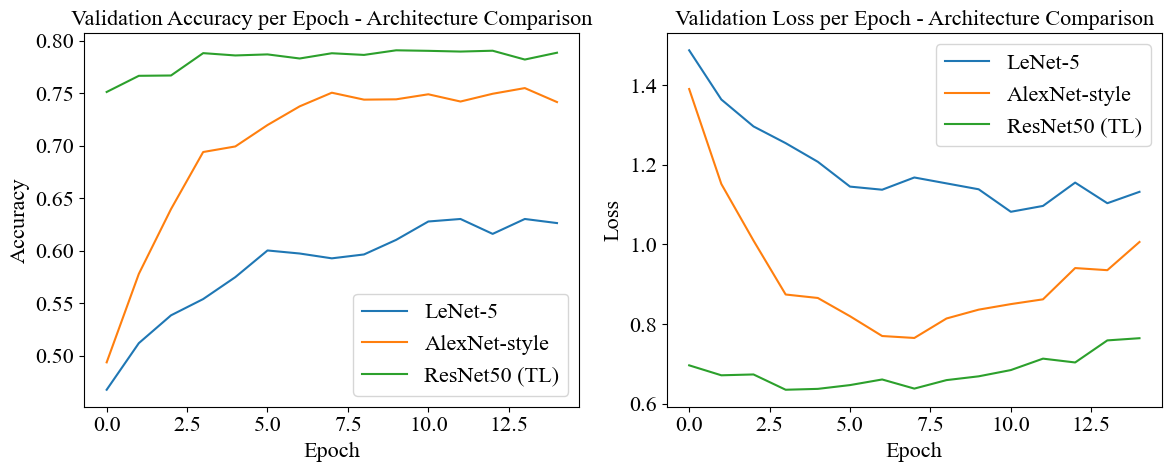


--- Architecture Comparison (final epoch values) ---
LeNet-5         -> Val Accuracy: 0.6263
AlexNet-style   -> Val Accuracy: 0.7416
ResNet50 (TL)   -> Val Accuracy: 0.7856


In [15]:
# ============================================================
# Architecture Comparison - epoch-wise line graphs (all hardcoded)
# ============================================================

# LeNet-5 (from your training log)
lenet_val_accuracy = [0.4675, 0.5119, 0.5384, 0.5539, 0.5748, 0.6002, 0.5973,
                       0.5927, 0.5964, 0.6103, 0.6278, 0.6302, 0.6160, 0.6302, 0.6263]
lenet_val_loss = [1.4873, 1.3638, 1.2962, 1.2542, 1.2074, 1.1451, 1.1373,
                   1.1680, 1.1532, 1.1384, 1.0819, 1.0966, 1.1552, 1.1034, 1.1320]

# AlexNet-style (from your training log)
alexnet_val_accuracy = [0.4936, 0.5779, 0.6396, 0.6940, 0.6993, 0.7197, 0.7375,
                         0.7505, 0.7439, 0.7442, 0.7490, 0.7421, 0.7495, 0.7549, 0.7416]
alexnet_val_loss = [1.3901, 1.1517, 1.0096, 0.8742, 0.8655, 0.8197, 0.7700,
                     0.7651, 0.8140, 0.8362, 0.8501, 0.8621, 0.9406, 0.9353, 1.0061]

# ResNet50 - hardcoded from your earlier fixed-preprocessing run
resnet_val_accuracy = [0.7512, 0.7666, 0.7669, 0.7882, 0.7860, 0.7870, 0.7831,
                        0.7881, 0.7865, 0.7909, 0.7904, 0.7897, 0.7905, 0.7821, 0.7886]
resnet_val_loss = [0.6964, 0.6714, 0.6735, 0.6351, 0.6373, 0.6468, 0.6609,
                    0.6380, 0.6593, 0.6688, 0.6845, 0.7132, 0.7036, 0.7590, 0.7645]

# Final test accuracies / params / times (fill in if not already in memory)
arch_results = {
    'LeNet-5': 0.6263,        # last val_accuracy as proxy if test_acc not separately stored
    'AlexNet-style': 0.7416,
    'ResNet50 (TL)': 0.7856
}
arch_times = {
    'LeNet-5': None,          # fill in from your run if available
    'AlexNet-style': None,
    'ResNet50 (TL)': None
}
arch_params = {
    'LeNet-5': None,
    'AlexNet-style': None,
    'ResNet50 (TL)': None
}

# ------------------------------------------------------------
# Epoch-wise line graph comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lenet_val_accuracy, label='LeNet-5')
plt.plot(alexnet_val_accuracy, label='AlexNet-style')
plt.plot(resnet_val_accuracy, label='ResNet50 (TL)')
plt.title("Validation Accuracy per Epoch - Architecture Comparison")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lenet_val_loss, label='LeNet-5')
plt.plot(alexnet_val_loss, label='AlexNet-style')
plt.plot(resnet_val_loss, label='ResNet50 (TL)')
plt.title("Validation Loss per Epoch - Architecture Comparison")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
save_eps_or_pdf("architecture_comparison_epochwise")
plt.show()

print("\n--- Architecture Comparison (final epoch values) ---")
for name in arch_results:
    print(f"{name:15s} -> Val Accuracy: {arch_results[name]:.4f}")

Using subset: (10000, 64, 64, 3), Test subset: (2000, 64, 64, 3)
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3590 - loss: 1.8034 - val_accuracy: 0.5150 - val_loss: 1.4507
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5021 - loss: 1.4421 - val_accuracy: 0.5335 - val_loss: 1.3351
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5416 - loss: 1.3241 - val_accuracy: 0.5760 - val_loss: 1.2328
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5565 - loss: 1.2550 - val_accuracy: 0.5870 - val_loss: 1.1798
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5845 - loss: 1.2103 - val_accuracy: 0.5975 - val_loss: 1.1654
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5945 - loss: 1.1589 - val_accuracy: 0.6120 - val_loss: 1.1352
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6080 - loss: 1.1241 - val_accuracy: 0.6175 - val_loss: 1.1359
Epoch 8/15
250/250 ━━━━━━━━━━━━

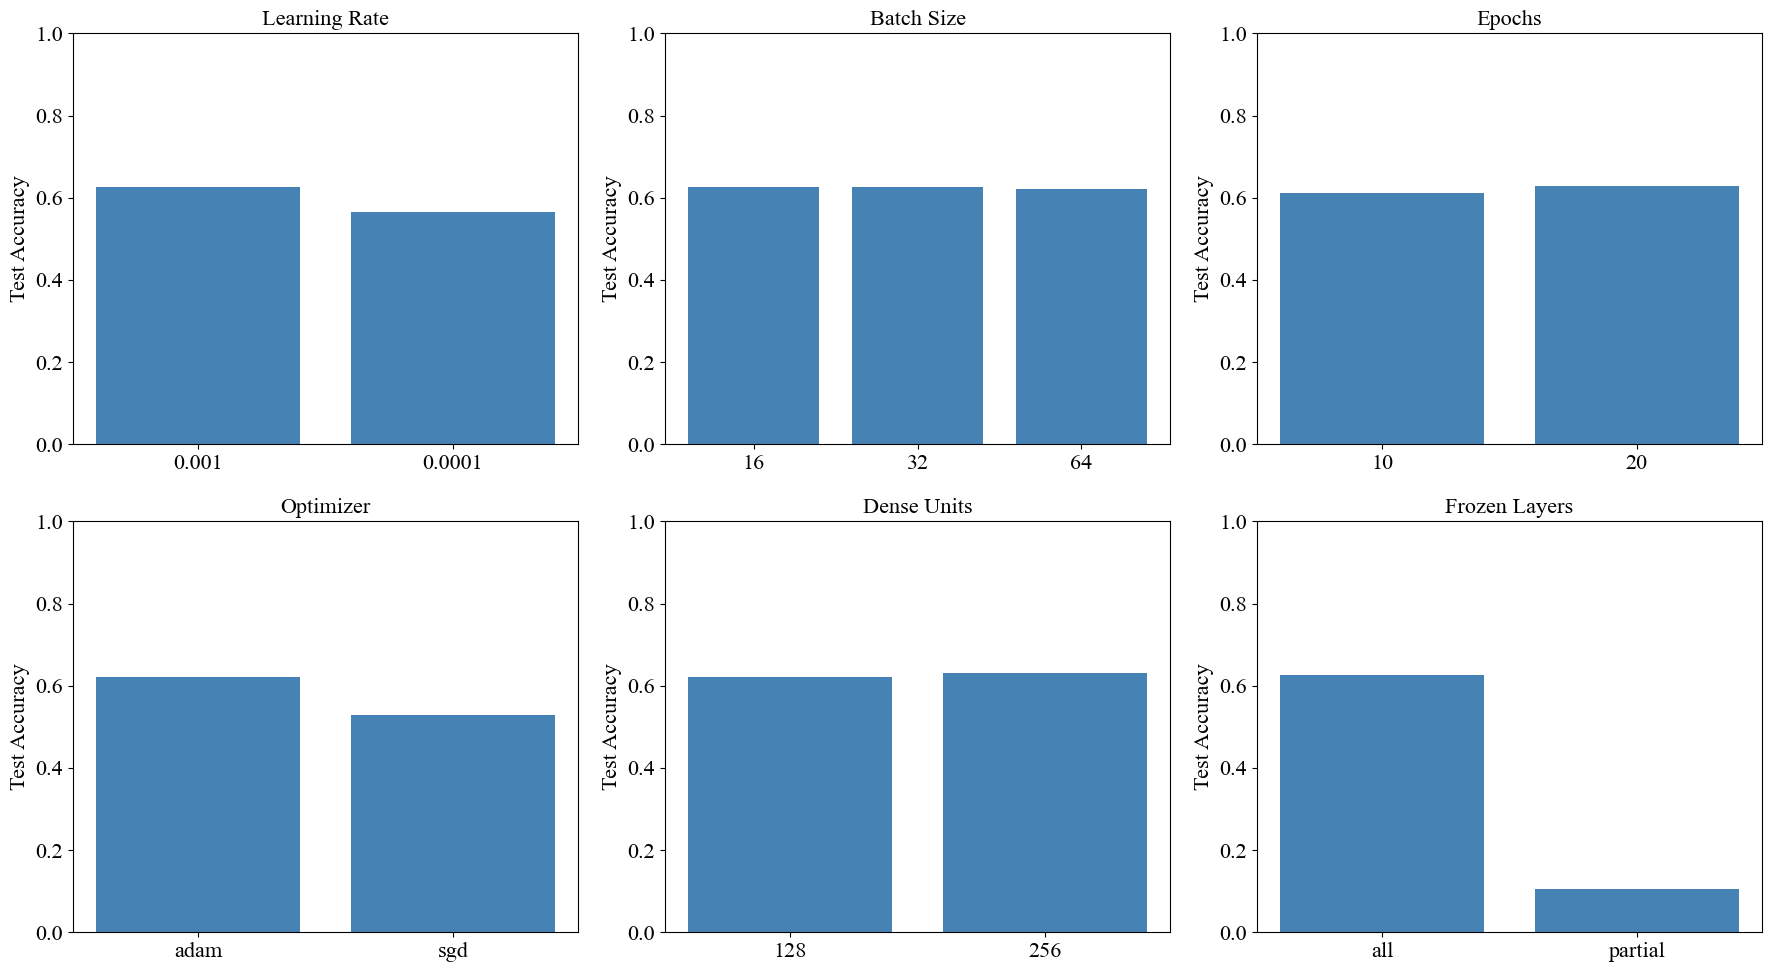

In [28]:
# ============================================================
# Full Hyperparameter Study (Section 16) - reduced dataset, full epochs
# One-Factor-at-a-Time comparison using VGG16 transfer learning
# ============================================================

# Use a reduced subset for speed (adjust size as needed)
SUBSET_SIZE = 10000
idx = np.random.RandomState(42).choice(len(x_train_r), SUBSET_SIZE, replace=False)
x_sub = x_train_r[idx]
y_sub = y_train_cat[idx]

idx_test = np.random.RandomState(42).choice(len(x_test_r), 2000, replace=False)
x_test_sub = x_test_r[idx_test]
y_test_sub = y_test_cat[idx_test]

print(f"Using subset: {x_sub.shape}, Test subset: {x_test_sub.shape}")

# Baseline configuration (used unless the row under test overrides it)
BASE_LR = 0.001
BASE_BATCH = 32
BASE_EPOCHS = 15
BASE_OPTIMIZER = 'adam'
BASE_DENSE_UNITS = 256
BASE_FROZEN = 'all'

def build_vgg_variant(lr=BASE_LR, optimizer_name=BASE_OPTIMIZER,
                       dense_units=BASE_DENSE_UNITS, frozen=BASE_FROZEN):
    base = VGG16(weights='imagenet', include_top=False,
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if frozen == 'all':
        base.trainable = False
    else:  # partial - unfreeze last block
        base.trainable = True
        for layer in base.layers:
            if not layer.name.startswith('block5'):
                layer.trainable = False

    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    opt = (tf.keras.optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam'
           else tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9))

    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return m


def run_experiment(config_name, value_label, **kwargs):
    """kwargs override baseline params; batch_size/epochs handled separately"""
    batch_size = kwargs.pop('batch_size', BASE_BATCH)
    epochs = kwargs.pop('epochs', BASE_EPOCHS)

    m = build_vgg_variant(**kwargs)
    start = time.time()
    h = m.fit(x_sub, y_sub, batch_size=batch_size, epochs=epochs,
              validation_split=0.2, verbose=1)
    elapsed = time.time() - start
    _, acc = m.evaluate(x_test_sub, y_test_sub, verbose=0)

    print(f"[{config_name}={value_label}] -> Test Accuracy: {acc:.4f}, Time: {elapsed:.2f}s")
    return {'config': config_name, 'value': value_label, 'accuracy': acc,
            'time': elapsed, 'history': h}


all_results = []

# ---- Row 1: Learning Rate ----
for lr in [0.001, 0.0001]:
    all_results.append(run_experiment('Learning Rate', lr, lr=lr))

# ---- Row 2: Batch Size ----
for bs in [16, 32, 64]:
    all_results.append(run_experiment('Batch Size', bs, batch_size=bs))

# ---- Row 3: Epochs ----
for ep in [10, 20]:
    all_results.append(run_experiment('Epochs', ep, epochs=ep))

# ---- Row 4: Optimizer ----
for opt in ['adam', 'sgd']:
    all_results.append(run_experiment('Optimizer', opt, optimizer_name=opt))

# ---- Row 5: Dense Units ----
for du in [128, 256]:
    all_results.append(run_experiment('Dense Units', du, dense_units=du))

# ---- Row 6: Frozen Layers ----
for fr in ['all', 'partial']:
    all_results.append(run_experiment('Frozen Layers', fr, frozen=fr))

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
print("\n\n=== Hyperparameter Study Summary ===")
print(f"{'Hyperparameter':<18}{'Value':<12}{'Accuracy':<12}{'Time (s)':<10}")
for r in all_results:
    print(f"{r['config']:<18}{str(r['value']):<12}{r['accuracy']:<12.4f}{r['time']:<10.2f}")

# ------------------------------------------------------------
# Plot: accuracy comparison per hyperparameter group
# ------------------------------------------------------------
configs = sorted(set(r['config'] for r in all_results), key=lambda c: [r['config'] for r in all_results].index(c))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cfg in enumerate(configs):
    subset = [r for r in all_results if r['config'] == cfg]
    labels = [str(r['value']) for r in subset]
    accs = [r['accuracy'] for r in subset]
    axes[i].bar(labels, accs, color='steelblue')
    axes[i].set_title(cfg)
    axes[i].set_ylabel("Test Accuracy")
    axes[i].set_ylim(0, 1)

plt.tight_layout()
save_eps_or_pdf("hyperparameter_study_summary")
plt.show()

Parsed runs: ['Learning Rate=0.001', 'Learning Rate=0.0001', 'Batch Size=16', 'Batch Size=32', 'Batch Size=64', 'Epochs=10', 'Epochs=20', 'Optimizer=adam', 'Optimizer=sgd', 'Dense Units=128', 'Dense Units=256', 'Frozen Layers=all', 'Frozen Layers=partial']


learning_rate_epochwise.eps saved (40.5 KB)


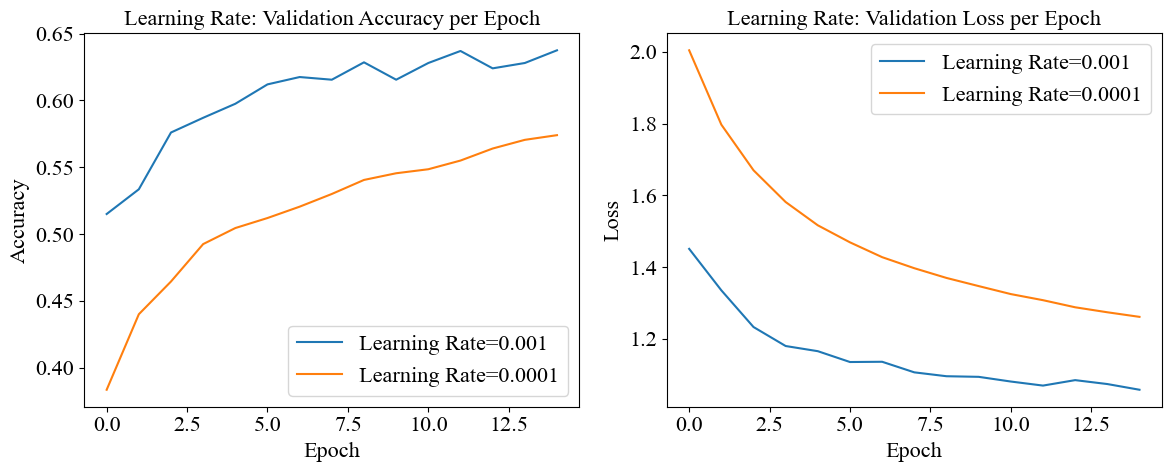

batch_size_epochwise.eps saved (42.2 KB)


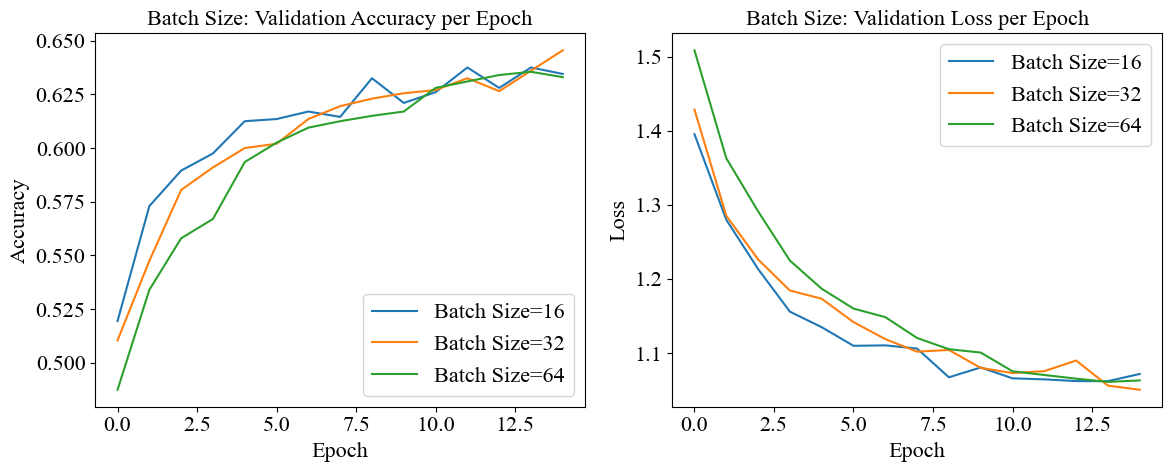

epochs_epochwise.eps saved (35.1 KB)


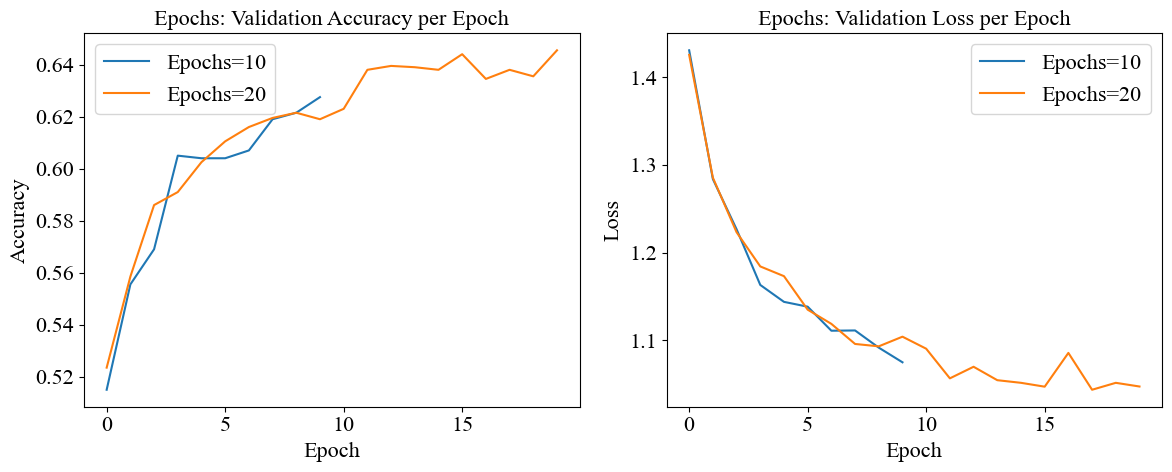

optimizer_epochwise.eps saved (41.9 KB)


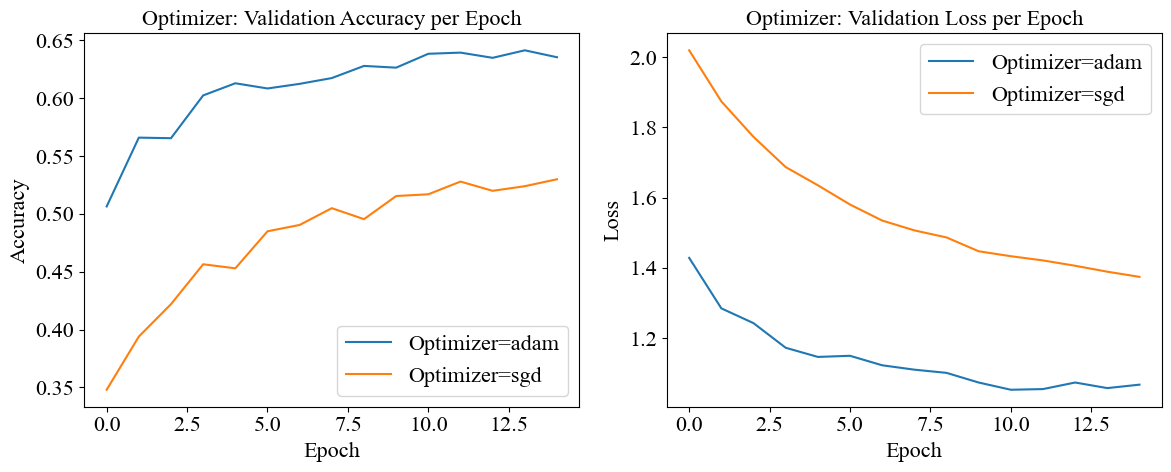

dense_units_epochwise.eps saved (40.5 KB)


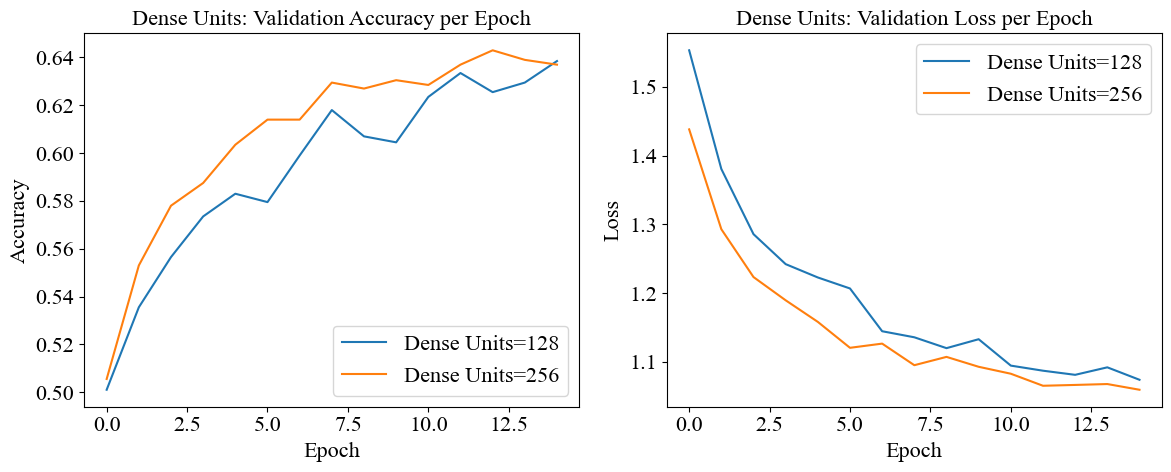

frozen_layers_epochwise.eps saved (40.7 KB)


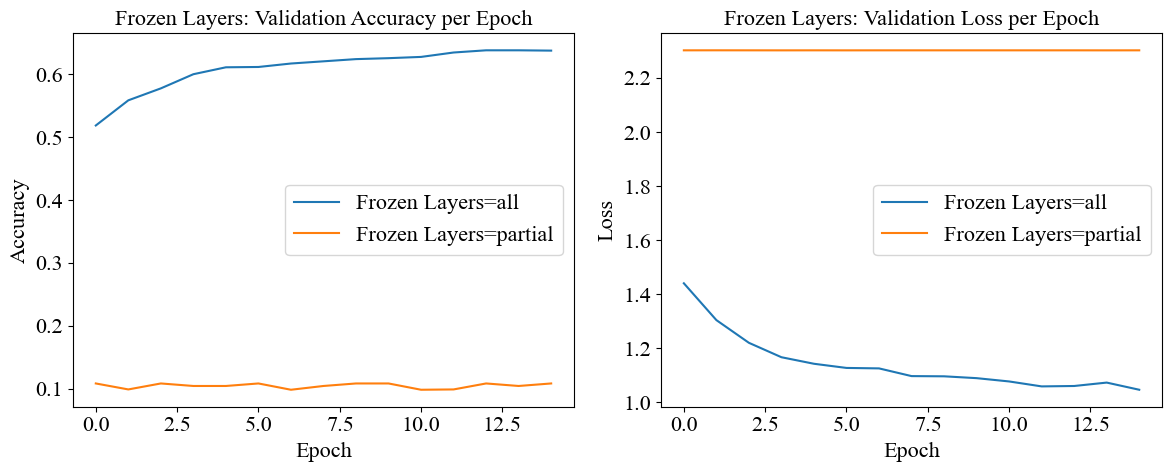

In [30]:
import re
import matplotlib.pyplot as plt

log_text = """Using subset: (10000, 64, 64, 3), Test subset: (2000, 64, 64, 3)
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3590 - loss: 1.8034 - val_accuracy: 0.5150 - val_loss: 1.4507
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5021 - loss: 1.4421 - val_accuracy: 0.5335 - val_loss: 1.3351
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5416 - loss: 1.3241 - val_accuracy: 0.5760 - val_loss: 1.2328
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5565 - loss: 1.2550 - val_accuracy: 0.5870 - val_loss: 1.1798
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5845 - loss: 1.2103 - val_accuracy: 0.5975 - val_loss: 1.1654
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5945 - loss: 1.1589 - val_accuracy: 0.6120 - val_loss: 1.1352
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6080 - loss: 1.1241 - val_accuracy: 0.6175 - val_loss: 1.1359
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6237 - loss: 1.0924 - val_accuracy: 0.6155 - val_loss: 1.1064
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6279 - loss: 1.0764 - val_accuracy: 0.6285 - val_loss: 1.0956
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6352 - loss: 1.0390 - val_accuracy: 0.6155 - val_loss: 1.0939
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6490 - loss: 1.0164 - val_accuracy: 0.6280 - val_loss: 1.0808
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6599 - loss: 0.9888 - val_accuracy: 0.6370 - val_loss: 1.0695
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6540 - loss: 0.9845 - val_accuracy: 0.6240 - val_loss: 1.0847
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6727 - loss: 0.9509 - val_accuracy: 0.6280 - val_loss: 1.0738
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6741 - loss: 0.9342 - val_accuracy: 0.6375 - val_loss: 1.0579
[Learning Rate=0.001] -> Test Accuracy: 0.6265, Time: 106.96s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.1622 - loss: 2.3005 - val_accuracy: 0.3835 - val_loss: 2.0042
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3088 - loss: 1.9645 - val_accuracy: 0.4400 - val_loss: 1.7970
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3829 - loss: 1.7929 - val_accuracy: 0.4645 - val_loss: 1.6698
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4234 - loss: 1.6791 - val_accuracy: 0.4925 - val_loss: 1.5812
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4552 - loss: 1.6049 - val_accuracy: 0.5045 - val_loss: 1.5163
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4729 - loss: 1.5447 - val_accuracy: 0.5120 - val_loss: 1.4688
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.4930 - loss: 1.4919 - val_accuracy: 0.5205 - val_loss: 1.4275
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4991 - loss: 1.4638 - val_accuracy: 0.5300 - val_loss: 1.3967
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5149 - loss: 1.4197 - val_accuracy: 0.5405 - val_loss: 1.3696
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5293 - loss: 1.3929 - val_accuracy: 0.5455 - val_loss: 1.3469
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5299 - loss: 1.3704 - val_accuracy: 0.5485 - val_loss: 1.3246
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5390 - loss: 1.3451 - val_accuracy: 0.5550 - val_loss: 1.3076
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5476 - loss: 1.3186 - val_accuracy: 0.5640 - val_loss: 1.2878
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5544 - loss: 1.3094 - val_accuracy: 0.5705 - val_loss: 1.2739
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5598 - loss: 1.2867 - val_accuracy: 0.5740 - val_loss: 1.2611
[Learning Rate=0.0001] -> Test Accuracy: 0.5660, Time: 105.86s
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3946 - loss: 1.7246 - val_accuracy: 0.5195 - val_loss: 1.3953
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5136 - loss: 1.3944 - val_accuracy: 0.5730 - val_loss: 1.2799
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5496 - loss: 1.2903 - val_accuracy: 0.5895 - val_loss: 1.2134
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5748 - loss: 1.2106 - val_accuracy: 0.5975 - val_loss: 1.1559
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5913 - loss: 1.1737 - val_accuracy: 0.6125 - val_loss: 1.1349
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6026 - loss: 1.1234 - val_accuracy: 0.6135 - val_loss: 1.1098
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6115 - loss: 1.1085 - val_accuracy: 0.6170 - val_loss: 1.1104
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6323 - loss: 1.0612 - val_accuracy: 0.6145 - val_loss: 1.1061
Epoch 9/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6351 - loss: 1.0382 - val_accuracy: 0.6325 - val_loss: 1.0673
Epoch 10/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6440 - loss: 1.0186 - val_accuracy: 0.6210 - val_loss: 1.0806
Epoch 11/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6463 - loss: 0.9938 - val_accuracy: 0.6260 - val_loss: 1.0659
Epoch 12/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6660 - loss: 0.9636 - val_accuracy: 0.6375 - val_loss: 1.0645
Epoch 13/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6649 - loss: 0.9466 - val_accuracy: 0.6280 - val_loss: 1.0622
Epoch 14/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6695 - loss: 0.9302 - val_accuracy: 0.6375 - val_loss: 1.0621
Epoch 15/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6773 - loss: 0.9040 - val_accuracy: 0.6345 - val_loss: 1.0718
[Batch Size=16] -> Test Accuracy: 0.6255, Time: 121.10s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3744 - loss: 1.7870 - val_accuracy: 0.5105 - val_loss: 1.4285
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4980 - loss: 1.4357 - val_accuracy: 0.5475 - val_loss: 1.2853
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5485 - loss: 1.3088 - val_accuracy: 0.5805 - val_loss: 1.2264
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5673 - loss: 1.2454 - val_accuracy: 0.5910 - val_loss: 1.1844
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5785 - loss: 1.1948 - val_accuracy: 0.6000 - val_loss: 1.1733
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5997 - loss: 1.1476 - val_accuracy: 0.6020 - val_loss: 1.1418
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6105 - loss: 1.1165 - val_accuracy: 0.6135 - val_loss: 1.1188
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6217 - loss: 1.0892 - val_accuracy: 0.6195 - val_loss: 1.1019
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6224 - loss: 1.0692 - val_accuracy: 0.6230 - val_loss: 1.1042
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6429 - loss: 1.0285 - val_accuracy: 0.6255 - val_loss: 1.0800
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6446 - loss: 1.0132 - val_accuracy: 0.6270 - val_loss: 1.0730
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6551 - loss: 0.9863 - val_accuracy: 0.6325 - val_loss: 1.0756
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6536 - loss: 0.9777 - val_accuracy: 0.6265 - val_loss: 1.0899
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6618 - loss: 0.9511 - val_accuracy: 0.6360 - val_loss: 1.0561
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6702 - loss: 0.9243 - val_accuracy: 0.6455 - val_loss: 1.0505
[Batch Size=32] -> Test Accuracy: 0.6270, Time: 105.62s
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.3530 - loss: 1.8663 - val_accuracy: 0.4875 - val_loss: 1.5085
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.4886 - loss: 1.4867 - val_accuracy: 0.5340 - val_loss: 1.3629
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5340 - loss: 1.3577 - val_accuracy: 0.5580 - val_loss: 1.2913
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5599 - loss: 1.2778 - val_accuracy: 0.5670 - val_loss: 1.2248
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5730 - loss: 1.2347 - val_accuracy: 0.5935 - val_loss: 1.1868
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5920 - loss: 1.1787 - val_accuracy: 0.6025 - val_loss: 1.1600
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5957 - loss: 1.1525 - val_accuracy: 0.6095 - val_loss: 1.1485
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6150 - loss: 1.1208 - val_accuracy: 0.6125 - val_loss: 1.1203
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6242 - loss: 1.0926 - val_accuracy: 0.6150 - val_loss: 1.1052
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6345 - loss: 1.0710 - val_accuracy: 0.6170 - val_loss: 1.1007
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6356 - loss: 1.0472 - val_accuracy: 0.6280 - val_loss: 1.0754
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6470 - loss: 1.0238 - val_accuracy: 0.6310 - val_loss: 1.0704
Epoch 13/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6459 - loss: 1.0042 - val_accuracy: 0.6340 - val_loss: 1.0655
Epoch 14/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6668 - loss: 0.9778 - val_accuracy: 0.6355 - val_loss: 1.0611
Epoch 15/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6654 - loss: 0.9632 - val_accuracy: 0.6330 - val_loss: 1.0631
[Batch Size=64] -> Test Accuracy: 0.6220, Time: 112.41s
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3785 - loss: 1.7612 - val_accuracy: 0.5150 - val_loss: 1.4307
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5063 - loss: 1.4056 - val_accuracy: 0.5555 - val_loss: 1.2839
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5494 - loss: 1.2892 - val_accuracy: 0.5690 - val_loss: 1.2267
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5686 - loss: 1.2255 - val_accuracy: 0.6050 - val_loss: 1.1632
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5984 - loss: 1.1814 - val_accuracy: 0.6040 - val_loss: 1.1439
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6039 - loss: 1.1392 - val_accuracy: 0.6040 - val_loss: 1.1384
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6166 - loss: 1.0976 - val_accuracy: 0.6070 - val_loss: 1.1110
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6255 - loss: 1.0770 - val_accuracy: 0.6190 - val_loss: 1.1113
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6338 - loss: 1.0406 - val_accuracy: 0.6215 - val_loss: 1.0917
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6440 - loss: 1.0158 - val_accuracy: 0.6275 - val_loss: 1.0750
[Epochs=10] -> Test Accuracy: 0.6120, Time: 72.57s
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.3771 - loss: 1.7800 - val_accuracy: 0.5235 - val_loss: 1.4255
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5157 - loss: 1.4177 - val_accuracy: 0.5585 - val_loss: 1.2855
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5481 - loss: 1.3056 - val_accuracy: 0.5860 - val_loss: 1.2233
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5670 - loss: 1.2428 - val_accuracy: 0.5910 - val_loss: 1.1843
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5865 - loss: 1.1847 - val_accuracy: 0.6025 - val_loss: 1.1732
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6065 - loss: 1.1354 - val_accuracy: 0.6105 - val_loss: 1.1350
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6136 - loss: 1.1103 - val_accuracy: 0.6160 - val_loss: 1.1188
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6234 - loss: 1.0748 - val_accuracy: 0.6195 - val_loss: 1.0959
Epoch 9/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6338 - loss: 1.0502 - val_accuracy: 0.6215 - val_loss: 1.0932
Epoch 10/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6486 - loss: 1.0151 - val_accuracy: 0.6190 - val_loss: 1.1042
Epoch 11/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6464 - loss: 1.0064 - val_accuracy: 0.6230 - val_loss: 1.0905
Epoch 12/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6562 - loss: 0.9775 - val_accuracy: 0.6380 - val_loss: 1.0567
Epoch 13/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6678 - loss: 0.9515 - val_accuracy: 0.6395 - val_loss: 1.0699
Epoch 14/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6752 - loss: 0.9300 - val_accuracy: 0.6390 - val_loss: 1.0546
Epoch 15/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6861 - loss: 0.9085 - val_accuracy: 0.6380 - val_loss: 1.0516
Epoch 16/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6845 - loss: 0.8904 - val_accuracy: 0.6440 - val_loss: 1.0472
Epoch 17/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6931 - loss: 0.8763 - val_accuracy: 0.6345 - val_loss: 1.0857
Epoch 18/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7044 - loss: 0.8528 - val_accuracy: 0.6380 - val_loss: 1.0437
Epoch 19/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7095 - loss: 0.8407 - val_accuracy: 0.6355 - val_loss: 1.0516
Epoch 20/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.7103 - loss: 0.8259 - val_accuracy: 0.6455 - val_loss: 1.0474
[Epochs=20] -> Test Accuracy: 0.6280, Time: 143.98s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3726 - loss: 1.7722 - val_accuracy: 0.5065 - val_loss: 1.4286
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5124 - loss: 1.4226 - val_accuracy: 0.5660 - val_loss: 1.2848
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5454 - loss: 1.3000 - val_accuracy: 0.5655 - val_loss: 1.2427
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5696 - loss: 1.2363 - val_accuracy: 0.6025 - val_loss: 1.1726
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5864 - loss: 1.1943 - val_accuracy: 0.6130 - val_loss: 1.1465
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6096 - loss: 1.1366 - val_accuracy: 0.6085 - val_loss: 1.1497
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6146 - loss: 1.1046 - val_accuracy: 0.6125 - val_loss: 1.1227
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6221 - loss: 1.0867 - val_accuracy: 0.6175 - val_loss: 1.1102
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6306 - loss: 1.0534 - val_accuracy: 0.6280 - val_loss: 1.1011
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6425 - loss: 1.0228 - val_accuracy: 0.6265 - val_loss: 1.0736
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6520 - loss: 1.0047 - val_accuracy: 0.6385 - val_loss: 1.0530
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6590 - loss: 0.9851 - val_accuracy: 0.6395 - val_loss: 1.0549
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6655 - loss: 0.9670 - val_accuracy: 0.6350 - val_loss: 1.0736
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6720 - loss: 0.9424 - val_accuracy: 0.6415 - val_loss: 1.0577
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6796 - loss: 0.9161 - val_accuracy: 0.6355 - val_loss: 1.0675
[Optimizer=adam] -> Test Accuracy: 0.6215, Time: 110.25s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.1885 - loss: 2.2179 - val_accuracy: 0.3480 - val_loss: 2.0197
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2903 - loss: 1.9970 - val_accuracy: 0.3940 - val_loss: 1.8743
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3491 - loss: 1.8642 - val_accuracy: 0.4220 - val_loss: 1.7732
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3779 - loss: 1.7758 - val_accuracy: 0.4565 - val_loss: 1.6872
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4045 - loss: 1.7178 - val_accuracy: 0.4530 - val_loss: 1.6354
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4234 - loss: 1.6634 - val_accuracy: 0.4850 - val_loss: 1.5805
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4372 - loss: 1.6246 - val_accuracy: 0.4905 - val_loss: 1.5349
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4519 - loss: 1.5759 - val_accuracy: 0.5050 - val_loss: 1.5069
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4540 - loss: 1.5523 - val_accuracy: 0.4955 - val_loss: 1.4868
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4765 - loss: 1.5206 - val_accuracy: 0.5155 - val_loss: 1.4474
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4728 - loss: 1.4982 - val_accuracy: 0.5170 - val_loss: 1.4333
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4870 - loss: 1.4825 - val_accuracy: 0.5280 - val_loss: 1.4213
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4930 - loss: 1.4607 - val_accuracy: 0.5200 - val_loss: 1.4061
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5027 - loss: 1.4394 - val_accuracy: 0.5240 - val_loss: 1.3892
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5071 - loss: 1.4285 - val_accuracy: 0.5300 - val_loss: 1.3745
[Optimizer=sgd] -> Test Accuracy: 0.5295, Time: 101.78s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3144 - loss: 1.8963 - val_accuracy: 0.5010 - val_loss: 1.5531
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4672 - loss: 1.5408 - val_accuracy: 0.5355 - val_loss: 1.3805
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5174 - loss: 1.4083 - val_accuracy: 0.5565 - val_loss: 1.2857
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5361 - loss: 1.3406 - val_accuracy: 0.5735 - val_loss: 1.2421
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5614 - loss: 1.2827 - val_accuracy: 0.5830 - val_loss: 1.2227
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5652 - loss: 1.2484 - val_accuracy: 0.5795 - val_loss: 1.2067
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5825 - loss: 1.2191 - val_accuracy: 0.5990 - val_loss: 1.1445
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5925 - loss: 1.1770 - val_accuracy: 0.6180 - val_loss: 1.1357
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6035 - loss: 1.1493 - val_accuracy: 0.6070 - val_loss: 1.1199
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6050 - loss: 1.1396 - val_accuracy: 0.6045 - val_loss: 1.1329
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6176 - loss: 1.1117 - val_accuracy: 0.6235 - val_loss: 1.0945
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6233 - loss: 1.0838 - val_accuracy: 0.6335 - val_loss: 1.0871
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6304 - loss: 1.0709 - val_accuracy: 0.6255 - val_loss: 1.0811
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6344 - loss: 1.0570 - val_accuracy: 0.6295 - val_loss: 1.0920
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6346 - loss: 1.0511 - val_accuracy: 0.6385 - val_loss: 1.0739
[Dense Units=128] -> Test Accuracy: 0.6205, Time: 114.97s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3699 - loss: 1.7779 - val_accuracy: 0.5055 - val_loss: 1.4381
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5098 - loss: 1.4199 - val_accuracy: 0.5530 - val_loss: 1.2929
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5472 - loss: 1.3051 - val_accuracy: 0.5780 - val_loss: 1.2233
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5754 - loss: 1.2433 - val_accuracy: 0.5875 - val_loss: 1.1895
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5888 - loss: 1.1916 - val_accuracy: 0.6035 - val_loss: 1.1581
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6014 - loss: 1.1470 - val_accuracy: 0.6140 - val_loss: 1.1204
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6121 - loss: 1.1109 - val_accuracy: 0.6140 - val_loss: 1.1265
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6302 - loss: 1.0740 - val_accuracy: 0.6295 - val_loss: 1.0951
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6331 - loss: 1.0610 - val_accuracy: 0.6270 - val_loss: 1.1072
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6415 - loss: 1.0333 - val_accuracy: 0.6305 - val_loss: 1.0928
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6535 - loss: 1.0051 - val_accuracy: 0.6285 - val_loss: 1.0827
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6509 - loss: 0.9817 - val_accuracy: 0.6370 - val_loss: 1.0652
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6594 - loss: 0.9713 - val_accuracy: 0.6430 - val_loss: 1.0664
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6687 - loss: 0.9530 - val_accuracy: 0.6390 - val_loss: 1.0677
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6765 - loss: 0.9300 - val_accuracy: 0.6370 - val_loss: 1.0594
[Dense Units=256] -> Test Accuracy: 0.6305, Time: 109.87s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3691 - loss: 1.7877 - val_accuracy: 0.5185 - val_loss: 1.4406
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4991 - loss: 1.4232 - val_accuracy: 0.5585 - val_loss: 1.3044
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5504 - loss: 1.3067 - val_accuracy: 0.5775 - val_loss: 1.2204
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5635 - loss: 1.2387 - val_accuracy: 0.6000 - val_loss: 1.1671
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5905 - loss: 1.1793 - val_accuracy: 0.6110 - val_loss: 1.1429
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6043 - loss: 1.1372 - val_accuracy: 0.6115 - val_loss: 1.1275
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6164 - loss: 1.1080 - val_accuracy: 0.6170 - val_loss: 1.1258
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6244 - loss: 1.0787 - val_accuracy: 0.6205 - val_loss: 1.0973
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6308 - loss: 1.0551 - val_accuracy: 0.6240 - val_loss: 1.0965
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6432 - loss: 1.0204 - val_accuracy: 0.6255 - val_loss: 1.0897
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6490 - loss: 1.0062 - val_accuracy: 0.6275 - val_loss: 1.0775
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6600 - loss: 0.9811 - val_accuracy: 0.6345 - val_loss: 1.0592
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6640 - loss: 0.9556 - val_accuracy: 0.6380 - val_loss: 1.0607
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6727 - loss: 0.9417 - val_accuracy: 0.6380 - val_loss: 1.0733
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6769 - loss: 0.9250 - val_accuracy: 0.6375 - val_loss: 1.0468
[Frozen Layers=all] -> Test Accuracy: 0.6255, Time: 116.26s
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.1040 - loss: 2.3084 - val_accuracy: 0.1085 - val_loss: 2.3023
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0993 - loss: 2.3025 - val_accuracy: 0.0990 - val_loss: 2.3024
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.0999 - loss: 2.3024 - val_accuracy: 0.1085 - val_loss: 2.3023
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.1016 - loss: 2.3026 - val_accuracy: 0.1045 - val_loss: 2.3022
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0978 - loss: 2.3023 - val_accuracy: 0.1045 - val_loss: 2.3023
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0983 - loss: 2.3025 - val_accuracy: 0.1085 - val_loss: 2.3022
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1005 - loss: 2.3024 - val_accuracy: 0.0985 - val_loss: 2.3023
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1013 - loss: 2.3024 - val_accuracy: 0.1045 - val_loss: 2.3023
Epoch 9/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1018 - loss: 2.3023 - val_accuracy: 0.1085 - val_loss: 2.3023
Epoch 10/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0961 - loss: 2.3024 - val_accuracy: 0.1085 - val_loss: 2.3023
Epoch 11/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1006 - loss: 2.3024 - val_accuracy: 0.0985 - val_loss: 2.3023
Epoch 12/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.0965 - loss: 2.3023 - val_accuracy: 0.0990 - val_loss: 2.3023
Epoch 13/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0990 - loss: 2.3024 - val_accuracy: 0.1085 - val_loss: 2.3023
Epoch 14/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0959 - loss: 2.3024 - val_accuracy: 0.1045 - val_loss: 2.3022
Epoch 15/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1015 - loss: 2.3023 - val_accuracy: 0.1085 - val_loss: 2.3023
[Frozen Layers=partial] -> Test Accuracy: 0.1055, Time: 164.00s


=== Hyperparameter Study Summary ===
Hyperparameter    Value       Accuracy    Time (s)
Learning Rate     0.001       0.6265      106.96
Learning Rate     0.0001      0.5660      105.86
Batch Size        16          0.6255      121.10
Batch Size        32          0.6270      105.62
Batch Size        64          0.6220      112.41
Epochs            10          0.6120      72.57
Epochs            20          0.6280      143.98
Optimizer         adam        0.6215      110.25
Optimizer         sgd         0.5295      101.78
Dense Units       128         0.6205      114.97
Dense Units       256         0.6305      109.87
Frozen Layers     all         0.6255      116.26
Frozen Layers     partial     0.1055      164.00
hyperparameter_study_summary.eps saved (55.0 KB)"""

# Parse: split log into blocks per experiment run using the summary tags
pattern = re.compile(
    r"Epoch \d+/(\d+)\n.*?accuracy: ([\d.]+) - loss: ([\d.]+) - val_accuracy: ([\d.]+) - val_loss: ([\d.]+)"
)

# Split by "[Hyperparam=value]" markers which end each run
run_marker = re.compile(r"\[(.*?)=(.*?)\] -> Test Accuracy: ([\d.]+), Time: ([\d.]+)s")

blocks = re.split(r"(\[.*?\] -> Test Accuracy: [\d.]+, Time: [\d.]+s)", log_text)

results = {}
current_config = None
current_epochs = []

i = 0
while i < len(blocks):
    block = blocks[i]
    marker_match = run_marker.match(block.strip()) if block.strip().startswith('[') else None
    if marker_match:
        # this block IS the summary line; the epochs text was in the previous block
        config, value, test_acc, train_time = marker_match.groups()
        key = f"{config}={value}"
        # previous block (i-1) has the epoch data
        epoch_data = blocks[i-1]
        matches = pattern.findall(epoch_data)
        val_acc = [float(m[3]) for m in matches]
        val_loss = [float(m[4]) for m in matches]
        results[key] = {'val_accuracy': val_acc, 'val_loss': val_loss,
                         'test_acc': float(test_acc), 'time': float(train_time)}
    i += 1

print("Parsed runs:", list(results.keys()))

# ------------------------------------------------------------
# Plot each hyperparameter group as epoch-wise line graphs
# ------------------------------------------------------------
groups = {
    'Learning Rate': ['Learning Rate=0.001', 'Learning Rate=0.0001'],
    'Batch Size': ['Batch Size=16', 'Batch Size=32', 'Batch Size=64'],
    'Epochs': ['Epochs=10', 'Epochs=20'],
    'Optimizer': ['Optimizer=adam', 'Optimizer=sgd'],
    'Dense Units': ['Dense Units=128', 'Dense Units=256'],
    'Frozen Layers': ['Frozen Layers=all', 'Frozen Layers=partial'],
}

for group_name, keys in groups.items():
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for k in keys:
        if k in results:
            plt.plot(results[k]['val_accuracy'], label=k)
    plt.title(f"{group_name}: Validation Accuracy per Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

    plt.subplot(1, 2, 2)
    for k in keys:
        if k in results:
            plt.plot(results[k]['val_loss'], label=k)
    plt.title(f"{group_name}: Validation Loss per Epoch")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

    plt.tight_layout()
    fname = group_name.lower().replace(' ', '_') + '_epochwise'
    save_eps_or_pdf(fname)
    plt.show()

Using subset: (10000, 64, 64, 3), Test subset: (2000, 64, 64, 3)
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3689 - loss: 1.7904 - val_accuracy: 0.5160 - val_loss: 1.4447
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5079 - loss: 1.4253 - val_accuracy: 0.5505 - val_loss: 1.2883
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5456 - loss: 1.2983 - val_accuracy: 0.5670 - val_loss: 1.2448
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5702 - loss: 1.2396 - val_accuracy: 0.5855 - val_loss: 1.1841
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5869 - loss: 1.1912 - val_accuracy: 0.6040 - val_loss: 1.1582
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6012 - loss: 1.1482 - val_accuracy: 0.6105 - val_loss: 1.1316
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6129 - loss: 1.1100 - val_accuracy: 0.6070 - val_loss: 1.1115
Epoch 8/15
250/250 ━━━━━━━━━━━

[Frozen Layers=partial] -> Test Accuracy: 0.7485, Time: 167.49s
frozen_layers_epochwise_fixed.eps saved (38.6 KB)


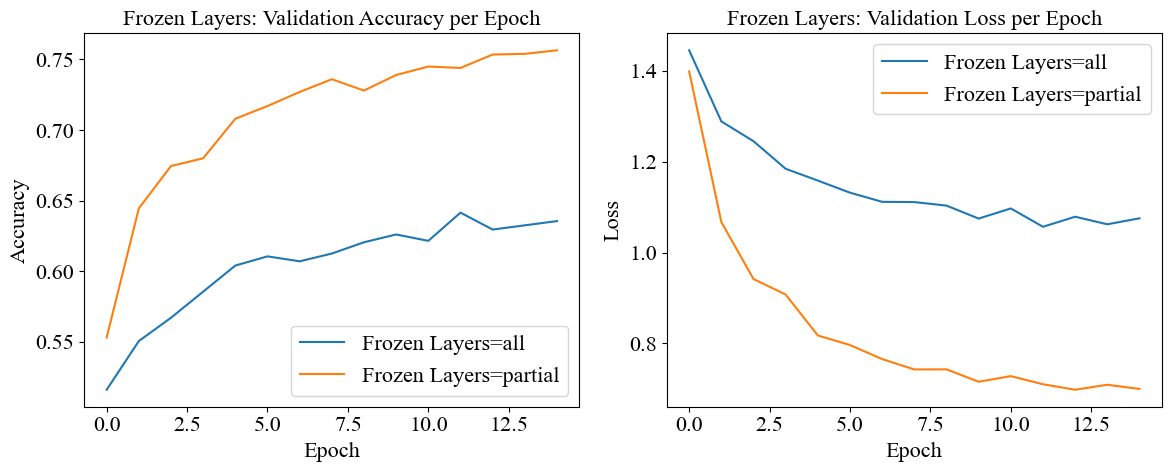


--- Frozen Layers Comparison (corrected) ---
Frozen Layers=all -> Accuracy: 0.6275, Time: 117.08s
Frozen Layers=partial -> Accuracy: 0.7485, Time: 167.49s


In [19]:
# ============================================================
# Fix: Frozen Layers comparison (All vs Partial) - self-contained
# Uses lower LR for partial (fine-tuning) to avoid catastrophic forgetting
# ============================================================

# Baseline config
BASE_LR = 0.001
BASE_BATCH = 32
BASE_EPOCHS = 15
BASE_DENSE_UNITS = 256

# Reduced subset (same as original hyperparameter study)
SUBSET_SIZE = 10000
idx = np.random.RandomState(42).choice(len(x_train_r), SUBSET_SIZE, replace=False)
x_sub = x_train_r[idx]
y_sub = y_train_cat[idx]

idx_test = np.random.RandomState(42).choice(len(x_test_r), 2000, replace=False)
x_test_sub = x_test_r[idx_test]
y_test_sub = y_test_cat[idx_test]

print(f"Using subset: {x_sub.shape}, Test subset: {x_test_sub.shape}")

frozen_results = {}
frozen_histories_data = {}
frozen_times = {}

for frozen_mode in ['all', 'partial']:
    base = VGG16(weights='imagenet', include_top=False,
                 input_shape=(IMG_SIZE, IMG_SIZE, 3))

    if frozen_mode == 'all':
        base.trainable = False
        lr = BASE_LR
    else:
        base.trainable = True
        for layer in base.layers:
            if not layer.name.startswith('block5'):
                layer.trainable = False
        lr = 1e-5

    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(BASE_DENSE_UNITS, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    h = m.fit(x_sub, y_sub, batch_size=BASE_BATCH, epochs=BASE_EPOCHS,
              validation_split=0.2, verbose=1)
    elapsed = time.time() - start
    _, acc = m.evaluate(x_test_sub, y_test_sub, verbose=0)

    key = f"Frozen Layers={frozen_mode}"
    frozen_results[key] = acc
    frozen_histories_data[key] = {
        'val_accuracy': h.history['val_accuracy'],
        'val_loss': h.history['val_loss']
    }
    frozen_times[key] = elapsed
    print(f"[{key}] -> Test Accuracy: {acc:.4f}, Time: {elapsed:.2f}s")

# ------------------------------------------------------------
# Plot: epoch-wise comparison, all vs partial
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for k, v in frozen_histories_data.items():
    plt.plot(v['val_accuracy'], label=k)
plt.title("Frozen Layers: Validation Accuracy per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
for k, v in frozen_histories_data.items():
    plt.plot(v['val_loss'], label=k)
plt.title("Frozen Layers: Validation Loss per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
save_eps_or_pdf("frozen_layers_epochwise_fixed")
plt.show()

print("\n--- Frozen Layers Comparison (corrected) ---")
for k in frozen_results:
    print(f"{k} -> Accuracy: {frozen_results[k]:.4f}, Time: {frozen_times[k]:.2f}s")